# Aprendizado por reforço para alocação de exames em vigilância de arboviroses

**Notebook de demonstração.** Cada afirmação aqui é recalculada na execução —
dos CSVs de benchmark, de episódios rodados na hora, ou do próprio modelo
epidemiológico. Não há número digitado à mão.

| Parte | Conteúdo |
|---|---|
| **I** | O problema, a formalização como MDP, o modelo epidemiológico, o gerador espacial e a economia do ambiente |
| **II** | O agente: observação, arquitetura, PPO, e o problema de atribuição de crédito que travava o aprendizado |
| **III** | Resultados e **testes de robustez**: seeds inéditas, qualidade do médico, custo do exame, ablação de entradas, transferência de distribuição |

Documentos de apoio: `EXPERIMENTO_V4.md` (desenho experimental),
`RESUMO_SESSAO.md` (histórico), `notebooks/analise_v4.ipynb` (análise da
ablação de crédito).

### Roteiro sugerido (12 minutos)

| tempo | seção | a frase que resume |
|---|---|---|
| 2 min | **§1.5** economia do ambiente | "testar tudo uma vez rende +2782; não fazer nada, −64. É nesse intervalo que uma política de alocação pode ganhar." |
| 2 min | **§2.3** o problema de crédito | "o sinal existia na trajetória; a definição padrão de retorno o apagava — correlação 0,04 contra 0,99." |
| 2 min | **§3.1** os três braços | "mesma observação, mesma recompensa: +729 → +2678, vencendo em 10 de 10 surtos." |
| 2 min | **§3.3** qualidade do médico | "ele investiga 98% dos casos com médico ruim e 43% com médico bom — sem observar isso." |
| 2 min | **§3.3b** orçamento aleatório | "com o mesmo número de exames distribuídos ao acaso, o desempenho cai ~630 pontos. O ganho é da escolha." |
| 2 min | **§3.6 + §3.8** limites | "não transfere para outra distribuição espacial, e não se adapta ao preço do exame. São os próximos passos." |

Se sobrar tempo: **§3.7** (o mapa do último dia) é a figura que mais explica a
tarefa para quem chega agora, e **§1.3** mostra por que o modelo epidemiológico
precisou ser refeito.

In [1]:
from pathlib import Path
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

warnings.filterwarnings("ignore")
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ)); os.chdir(RAIZ)

SAIDA = RAIZ / "results" / "demo"; SAIDA.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "figure.facecolor": "white",
})
COR = {"A": "#b8912f", "B": "#2d6fb5", "C": "#1f8a5f",
       "fixa": "#8a8a8a", "alvo": "#c2453a", "aprendido": "#6b4fa0"}

from experiments import robustez as R

CFG = R.config_ambiente("kriging_v8")
ENV = CFG["env"]
print("ambiente de referência: kriging_v8 (mapa real do Rio + SEIR de literatura)")
print(f"mundo {ENV['size']}x{ENV['size']} | horizonte {ENV['epilength']} dias | "
      f"população da epidemia {ENV['episize']}")

ambiente de referência: kriging_v8 (mapa real do Rio + SEIR de literatura)
mundo 400x400 | horizonte 300 dias | população da epidemia 300


---
# Parte I — O problema e a modelagem

## 1.1 A tarefa

Uma vigilância epidemiológica recebe **notificações de casos suspeitos** de
arbovirose, dia após dia. Cada notificação traz um palpite clínico (dengue,
chikungunya ou "não é arbovirose") e uma localização. Dengue e chikungunya têm
apresentação clínica parecida, então o palpite erra com frequência.

Para cada caso, a vigilância pode:

- **aceitar o palpite clínico** e seguir adiante (custo zero);
- **pedir um exame laboratorial** (RT-PCR) — caro, e o laudo demora 5 dias;
- **investigar a vizinhança epidemiológica** — se há casos confirmados em volta,
  isso é evidência sobre qual doença é;
- **concluir** o caso (confirmar dengue, chikungunya ou descartar).

O problema **não** é classificar melhor que o médico. É decidir **em quais casos
vale gastar exame** — o orçamento é finito e a epidemia continua chegando.

## 1.2 Formalização

O ambiente é um **MDP parcialmente observável**, resolvido como MDP sobre a
observação (a política não carrega memória explícita; a informação acumulada
está na própria observação, que inclui os laudos já recebidos e o mapa de
confirmados construído pelo agente).

$$\max_{\pi}\; \mathbb{E}\Big[\textstyle\sum_{t} r_t \Big],\qquad
r_t = \underbrace{-c(a_t)}_{\text{custo imediato}}
      + \underbrace{\rho(a_t, y_i)}_{\text{desfecho, } 5\text{ dias depois}}
      + \underbrace{\beta(i)}_{\text{placar final do caso}}$$

- **Estado** $s_t$: a epidemia verdadeira (curvas SEIR das duas doenças, posição
  e doença real de cada caso) e o histórico de ações — o agente **não** observa
  a doença real nem a curva.
- **Observação** $o_t$: um caso por vez, com mapa, coordenadas e contexto (§2.1).
- **Ação** $a_t$: 7 opções discretas, abaixo. Uma máscara proíbe ações inválidas
  (por exemplo, repetir um exame já feito duas vezes).
- **Horizonte**: 300 dias de epidemia; cerca de 370 casos e 744 decisões por
  episódio.

In [2]:
acoes = pd.DataFrame([
    (0, "testar dengue",   f"-{ENV['test_cost']}", "laudo em 5 dias; sens. 0,95 / espec. 0,98"),
    (1, "testar chik",     f"-{ENV['test_cost']}", "idem"),
    (2, "confirmar por epidemiologia", f"-{ENV['epi_confirm_cost']}",
        f"olha raio {ENV['epi_radius']} do mapa de confirmados do próprio agente"),
    (3, "não fazer nada",  "0", "ação nula: mantém o diagnóstico do médico"),
    (4, "concluir dengue", "0", "+10 se certo, -20 se errado (entregue com atraso)"),
    (5, "concluir chik",   "0", "idem"),
    (6, "concluir outro",  "0", "idem"),
], columns=["id", "ação", "custo imediato", "observações"])
display(acoes.set_index("id"))

placar = pd.DataFrame([
    ("acerto no placar final", f"+{ENV.get('final_correct_bonus', 1.0)}", "por caso cujo diagnóstico final bate com a verdade"),
    ("erro no placar final", f"{ENV.get('penalty_misdiagnosed', -3.0)}", "por caso que termina com diagnóstico errado"),
    ("caso investigado e largado", f"{ENV['penalty_unresolved']}", "só para quem abriu investigação e não concluiu"),
    ("bônus de concluir investigado", f"+{ENV['shaping_conclude_bonus']}", "encurta o crédito da cadeia investigar → concluir"),
], columns=["componente", "valor", "quando"])
display(placar.set_index("componente"))

print("Ruído do processo (não observável pelo agente):")
print(f"  especificidade do médico ~ U{tuple(ENV['clinical_specificity'])} por episódio")
print(f"  casos que não são arbovirose: {ENV['other_prevalence']:.0%} "
      f"(médico reconhece só {ENV['other_recognition_prob']:.0%} deles)")
print(f"  exame: sens. {ENV['lab_sensitivity']}, espec. {ENV['lab_specificity']}, "
      f"inconclusivo {ENV['lab_inconclusive_prob']:.0%}, atraso {ENV['lab_delay_days']} dias")
print(f"  no máximo {ENV['max_case_revisits']} exames por caso")

,ação,custo imediato,observações
id,,,
0,testar dengue,-4.0,"laudo em 5 dias; sens. 0,95 / espec. 0,98"
1,testar chik,-4.0,idem
2,confirmar por epidemiologia,-4.0,olha raio 20 do mapa de confirmados do próprio...
3,não fazer nada,0,ação nula: mantém o diagnóstico do médico
4,concluir dengue,0,"+10 se certo, -20 se errado (entregue com atraso)"
5,concluir chik,0,idem
6,concluir outro,0,idem


,valor,quando
componente,,
acerto no placar final,+1.0,por caso cujo diagnóstico final bate com a ver...
erro no placar final,-3.0,por caso que termina com diagnóstico errado
caso investigado e largado,-10.0,só para quem abriu investigação e não concluiu
bônus de concluir investigado,+2.0,encurta o crédito da cadeia investigar → concluir


Ruído do processo (não observável pelo agente):
  especificidade do médico ~ U(0.5, 0.95) por episódio
  casos que não são arbovirose: 25% (médico reconhece só 15% deles)
  exame: sens. 0.95, espec. 0.98, inconclusivo 2%, atraso 5 dias
  no máximo 2 exames por caso


Três detalhes de modelagem que mudaram o comportamento do agente quando foram
corrigidos (histórico em `RESUMO_SESSAO.md`):

1. **"Não fazer nada" é a ação nula**, com custo zero. Não é uma escolha
   *errada*: é aceitar o diagnóstico do médico, e o caso é julgado pelo acerto
   desse palpite. Antes ela custava 0,1, o que fazia o agente pagar por existir.
2. **A penalidade de caso não resolvido só recai sobre quem investigou e
   largou.** Antes recaía sobre todo caso não concluído — inclusive os que o
   agente nunca tocou — e era somada em bloco no fim. O agente otimizava
   corretamente um sinal que mentia.
3. **A confirmação epidemiológica lê o mapa que o próprio agente construiu**
   (casos com laudo positivo), não a verdade do gerador. É isso que torna o
   exame um **investimento**: cada laudo positivo melhora a evidência disponível
   para casos futuros na região.

## 1.3 O modelo epidemiológico

As duas epidemias são geradas por um **SEIR determinístico** com transmissão
dependente da frequência:

$$\frac{dS}{dt} = -\beta\frac{SI}{N},\qquad
\frac{dE}{dt} = \beta\frac{SI}{N} - \sigma E,\qquad
\frac{dI}{dt} = \sigma E - \gamma I,\qquad
\frac{dR}{dt} = \gamma I$$

com $\beta = R_0\gamma$, $\sigma = 1/\text{latente}$, $\gamma = 1/\text{infeccioso}$.
A incidência de **casos notificáveis** por dia é $\sigma E(t)$ — a saída do
compartimento exposto.

**O período latente absorve a incubação extrínseca no mosquito.** Não é o
período intrínseco do paciente: é o que faz o **tempo de geração** do modelo
corresponder ao **intervalo serial** observado em campo (15–17 dias para dengue,
Aldstadt et al. 2012). Sem isso a epidemia corre rápido demais.

| | latente | infeccioso | geração | $R_0$ | fonte do $R_0$ |
|---|---:|---:|---:|---|---|
| dengue | 11 d | 5 d | 16 d | 1,25–1,70 | Villela et al. 2017 (Rio: 1,70 em 2002; 1,25 em 2012) |
| chikungunya | 8 d | 6 d | 14 d | 1,46–1,67 | Moreira et al. 2023 (1,56; IC 1,46–1,67) |

**Validação.** Para estágios exponenciais, a taxa de crescimento $r$ da fase
inicial se relaciona ao $R_0$ por
$R_0 = (1 + r\,T_{\text{lat}})(1 + r\,T_{\text{inf}})$, e o tamanho final da
epidemia satisfaz $z = 1 - e^{-R_0 z}$. As duas identidades são verificadas
abaixo, e estão travadas na suíte de testes — foi assim que o defeito do modelo
anterior apareceu.

R0 declarado -> R0 medido na curva gerada (população grande, semente 1e-6):
   1.25  ->  1.250
   1.50  ->  1.500
   1.70  ->  1.700


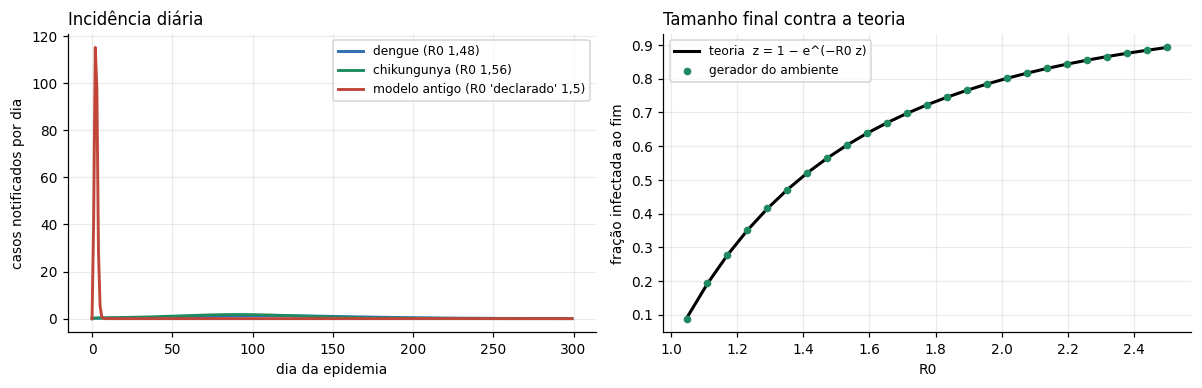

dengue (R0 1,48)                     5%→95% dos casos em 190 dias
chikungunya (R0 1,56)                5%→95% dos casos em 151 dias
modelo antigo (R0 'declarado' 1,5)   5%→95% dos casos em   3 dias


In [3]:
from dengue_envs.core.epi_model import (
    CHIK, DENGUE, final_size, legacy_sir_cumulative, seir_cumulative_cases)

def r0_efetivo(curva, params, inicio=10, fim=80):
    "R0 medido pela taxa de crescimento da fase exponencial."
    inc = np.diff(curva)[inicio:fim]
    r = np.polyfit(np.arange(len(inc)), np.log(np.maximum(inc, 1e-12)), 1)[0]
    return (1 + r * params.latent_days) * (1 + r * params.infectious_days)

print("R0 declarado -> R0 medido na curva gerada (população grande, semente 1e-6):")
for r0 in (1.25, 1.50, 1.70):
    c = seir_cumulative_cases(r0, DENGUE, 1e7, 200, initial_infected_fraction=1e-6)
    print(f"   {r0:.2f}  ->  {r0_efetivo(c, DENGUE):.3f}")

POP, DIAS = ENV["episize"], ENV["epilength"]
curvas = {
    "dengue (R0 1,48)": seir_cumulative_cases(1.48, DENGUE, POP, DIAS, initial_infected_fraction=0.01),
    "chikungunya (R0 1,56)": seir_cumulative_cases(1.56, CHIK, POP, DIAS, initial_infected_fraction=0.01),
    "modelo antigo (R0 'declarado' 1,5)": legacy_sir_cumulative(popsize=POP, epilength=DIAS, r0=1.5),
}
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
for (nome, c), cor in zip(curvas.items(), [COR["B"], COR["C"], COR["alvo"]]):
    a1.plot(np.diff(c, prepend=0), lw=1.9, color=cor, label=nome)
a1.set_xlabel("dia da epidemia"); a1.set_ylabel("casos notificados por dia")
a1.set_title("Incidência diária", loc="left"); a1.legend(fontsize=8)

r0s = np.linspace(1.05, 2.5, 25)
a2.plot(r0s, [final_size(r) for r in r0s], color="black", lw=2, label="teoria  z = 1 − e^(−R0 z)")
a2.scatter(r0s, [seir_cumulative_cases(r, DENGUE, 10_000, 2000, initial_infected_fraction=1e-4)[-1] / 10_000
                 for r in r0s], s=16, color=COR["C"], zorder=3, label="gerador do ambiente")
a2.set_xlabel("R0"); a2.set_ylabel("fração infectada ao fim"); a2.legend(fontsize=8)
a2.set_title("Tamanho final contra a teoria", loc="left")
fig.tight_layout(); fig.savefig(SAIDA / "modelo_seir.png", bbox_inches="tight"); plt.show()

def janela(c):
    t = c[-1]
    return int(np.searchsorted(c, 0.95 * t) - np.searchsorted(c, 0.05 * t))
for nome, c in curvas.items():
    print(f"{nome:36s} 5%→95% dos casos em {janela(c):3d} dias")

A curva vermelha é o modelo que o projeto usou até esta fase: a transmissão não
era dividida por $N$ e o período infeccioso era de 250 dias, então um $R_0$
declarado de 1,5 valia **225** na prática e a epidemia inteira cabia em poucos
dias. Toda a estrutura temporal do ambiente — sobreposição de casos, espera pelo
laudo, fase da epidemia — estava calibrada a esse pico artificial.

O modelo antigo continua no código sob `epi_model: legacy` (ainda o padrão, para
não alterar em silêncio resultados já produzidos); os ambientes v8 pedem `seir`
explicitamente.

## 1.4 O gerador espacial: kriging sobre o Rio

As posições dos casos são amostradas de $P(\text{célula} \mid \text{doença})$,
estimada por **Ordinary Kriging** sobre as notificações de dengue e chikungunya
do Rio de Janeiro em 2015–16. Cada episódio sorteia uma transformação rígida da
superfície (rotação 180°, espelhamentos) para o agente não decorar a geografia
de um único surto — a transformação é aplicada às duas doenças juntas, então a
dificuldade é preservada.

Isso substituiu um gerador sintético de dois focos gaussianos. A diferença não é
estética: no sintético, a **posição sozinha** dizia qual era a doença em 93,7%
dos casos — o exame era redundante, e não comprá-lo era a resposta correta. No
mapa real, a posição acerta 50,7% ± 2,4 entre duas classes, ou seja, quase nada.

grid das superfícies: (91, 145)  |  célula de 500 m


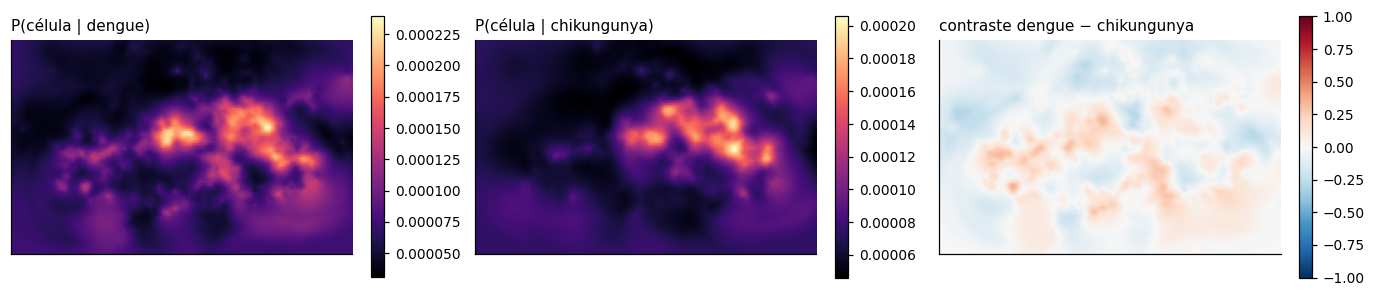

acerto usando SÓ a posição do caso: 53.8% (± 2.0%, 3 surtos) — entre duas classes, é quase cara-ou-coroa


In [4]:
from dengue_envs.data.kriging_generator import load_kriging_surfaces

sup = load_kriging_surfaces(RAIZ / "results/kriging/rio_2015_2016_kriging_surfaces.npz")
campos = {"dengue": sup.prob_dengue, "chikungunya": sup.prob_chik}
print(f"grid das superfícies: {sup.shape}  |  célula de {sup.cell_size:.0f} m")

fig, eixos = plt.subplots(1, 3, figsize=(12.5, 3.6))
for ax, (nome, campo) in zip(eixos, campos.items()):
    im = ax.imshow(campo, origin="lower", cmap="magma")
    ax.set_title(f"P(célula | {nome})", loc="left", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    fig.colorbar(im, ax=ax, fraction=0.035)

# Onde as duas superfícies discordam é toda a informação que a posição carrega.
a, b = sup.prob_dengue, sup.prob_chik
contraste = (a - b) / (a + b + 1e-12)
im = eixos[2].imshow(contraste, origin="lower", cmap="RdBu_r", vmin=-1, vmax=1)
eixos[2].set_title("contraste dengue − chikungunya", loc="left", fontsize=10)
eixos[2].set_xticks([]); eixos[2].set_yticks([]); eixos[2].grid(False)
fig.colorbar(im, ax=eixos[2], fraction=0.035)
fig.tight_layout(); fig.savefig(SAIDA / "kriging.png", bbox_inches="tight"); plt.show()

# Quanto a posição prediz a doença: o melhor classificador possível dado
# P(célula | doença) é escolher a doença mais provável naquela célula.
from dengue_envs.wrappers import make_env
# Sem `augment_surfaces`: a transformação rígida por episódio embaralharia a
# correspondência entre a superfície carregada aqui e o surto gerado. A
# dificuldade é a mesma (medido: 52,5 ± 1,1 com aumento contra 50,7 ± 2,4 sem).
env = make_env(R.config_ambiente("kriging_v8", augment_surfaces=False))
acertos = []
for s in (9001, 9002, 9003):
    env.reset(seed=s)
    casos = env.unwrapped.world.casedf
    ny, nx = a.shape
    ix = np.clip((casos["x"] / ENV["size"] * nx).astype(int), 0, nx - 1)
    iy = np.clip((casos["y"] / ENV["size"] * ny).astype(int), 0, ny - 1)
    palpite = (b[iy, ix] > a[iy, ix]).astype(int)
    acertos.append(float((palpite == casos["disease"].to_numpy()).mean()))
env.close()
print(f"acerto usando SÓ a posição do caso: {np.mean(acertos):.1%} "
      f"(± {np.std(acertos):.1%}, 3 surtos) — entre duas classes, é quase cara-ou-coroa")

## 1.5 A economia do ambiente

Antes de treinar qualquer coisa: **quanto vale a informação neste ambiente?**
Políticas fixas respondem isso sem aprendizado nenhum, e definem as referências
contra as quais o agente é julgado.

| política | o que faz |
|---|---|
| `clinical` | aceita todo palpite do médico; nunca gasta |
| `confirmall` | conclui todo caso pelo palpite clínico, sem exame |
| `testonce` | um exame por caso, depois conclui pelo laudo |
| `testtwice` | dois exames por caso |
| `random` | ação aleatória (controle) |

In [5]:
base = pd.read_csv(RAIZ / "results/baseline_v8seir_kriging/benchmark_mean.csv", index_col=0)
base_std = pd.read_csv(RAIZ / "results/baseline_v8seir_kriging/benchmark_std.csv", index_col=0)
tab = pd.DataFrame({
    "recompensa": base["Recompensa Total"].round(1),
    "± desvio (10 seeds)": base_std["Recompensa Total"].round(1),
    "acurácia": base["Acurácia Multiclasse"].round(3),
    "exames": base["Testes Realizados"].round(1),
}).sort_values("recompensa", ascending=False)
display(tab)

ALVO = base.loc["testonce", "Recompensa Total"]
PISO = base.loc["clinical", "Recompensa Total"]
print(f"melhor política fixa: testonce {ALVO:+.1f}   |   não fazer nada: clinical {PISO:+.1f}")
print(f"valor de um exame bem gasto: ~{(ALVO - PISO) / base.loc['testonce','Testes Realizados']:.1f} "
      f"pontos por exame, na média de testonce")

,recompensa,± desvio (10 seeds),acurácia,exames
agent,,,,
testonce,2782.1,199.0,0.960,368.7
testtwice,1050.9,144.1,0.950,737.3
confirmall,345.9,1698.0,0.710,0.0
clinical,-64.1,202.0,0.710,0.0
random,-6162.7,456.1,0.443,193.4


melhor política fixa: testonce +2782.1   |   não fazer nada: clinical -64.1
valor de um exame bem gasto: ~7.7 pontos por exame, na média de testonce


**Leitura.** Testar uma vez por caso é a melhor política fixa; testar duas vezes
gasta o dobro e rende bem menos. Entre não testar nada (−64) e testar tudo uma
vez (+2782) há um intervalo de ~2850 pontos: é esse o espaço onde uma política
de alocação pode ganhar — e, em princípio, superar `testonce`, gastando menos
exames nos casos em que o palpite clínico já basta.

Nada disso transfere entre distribuições: no gerador sintético a ordem se
inverte e `testtwice` é a melhor política fixa (§3.6).

---
# Parte II — O agente

## 2.1 O que ele observa

Uma decisão por passo, sobre **um caso**. A observação tem quatro partes:

| parte | forma | conteúdo |
|---|---|---|
| `map` | 6 × 100 × 100 | diagnóstico clínico, status dos dois exames, casos ativos hoje, e **densidade de confirmados** de cada doença — os dois últimos canais são o mapa que o próprio agente construiu com seus laudos |
| `case_coords` | 2 | posição do caso, normalizada |
| `context` | 16 | evidência sobre o médico (2), diagnóstico clínico do caso (3), resultado do exame de dengue (4) e de chik (4), confirmação epidemiológica (1), densidade local de confirmados (2) |
| `mask` | 7 | ações válidas — o ator soma $-\infty$ aos logits das inválidas |

As posições do `context` importam para a §3.5, em que cada bloco é zerado para
medir de que entrada a política realmente depende.

**Por que o contexto existe:** o encoder termina em `AdaptiveAvgPool2d(6,6)`, e
um mapa 100×100 vira 6×6 — a célula do caso individual se dissolve na média
(medido: alterar o diagnóstico do caso atual muda as features do mapa em 2e-04).
Sem o contexto o agente aprendia *quanto* testar, nunca *quais* casos testar.

In [6]:
import torch
from agents.ppo.network import build_actor_critic

env = make_env(CFG)
ator, critico = build_actor_critic(env, device="cpu", pooled_size=6)
est = torch.load(RAIZ / "results/ppo_v4c_credito_sem_tempo_s45/policy_final.pth",
                 map_location="cpu", weights_only=True)
ator.load_state_dict({k[len("policy.actor."):]: v for k, v in est.items()
                      if k.startswith("policy.actor.")})

print("espaço de observação:")
for chave, espaco in env.observation_space.spaces.items():
    print(f"   {chave:12s} {espaco}")

blocos = {"encoder do mapa (conv)": ator.trunk.map_encoder,
          "projeção do mapa": ator.trunk.map_proj,
          "coordenadas": ator.trunk.coord_encoder,
          "contexto": ator.trunk.context_encoder,
          "cabeça (política)": ator.net}
print("\nparâmetros por bloco:")
total = 0
for nome, bloco in blocos.items():
    n = sum(p.numel() for p in bloco.parameters()) if bloco is not None else 0
    total += n
    print(f"   {nome:26s} {n:>10,}")
print(f"   {'total do ator':26s} {total:>10,}")
env.close()

espaço de observação:
   case_coords  Box(0.0, 1.0, (2,), float32)
   context      Box(0.0, 1.0, (16,), float32)
   map          Box(0, 255, (6, 100, 100), uint8)
   mask         MultiBinary(7)

parâmetros por bloco:
   encoder do mapa (conv)         32,880
   projeção do mapa              295,040
   coordenadas                     4,352
   contexto                       18,688
   cabeça (política)              41,991
   total do ator                 392,951


## 2.2 O algoritmo: PPO

Política estocástica $\pi_\theta(a\mid o)$ e crítico $V_\phi(o)$, treinados com o
objetivo *clipped* do PPO:

$$L(\theta) = \mathbb{E}_t\Big[\min\big(\rho_t(\theta)\hat{A}_t,\;
\text{clip}(\rho_t(\theta), 1-\epsilon, 1+\epsilon)\hat{A}_t\big)\Big]
- c_v\,\mathbb{E}_t\big[(V_\phi - \hat{R}_t)^2\big]
+ c_H\,\mathbb{E}_t\big[H(\pi_\theta)\big],
\qquad \rho_t = \frac{\pi_\theta(a_t\mid o_t)}{\pi_{\theta_{old}}(a_t\mid o_t)}$$

A vantagem $\hat{A}_t$ vem do **GAE**:

$$\delta_t = r_t + \gamma V(o_{t+1}) - V(o_t),\qquad
\hat{A}_t = \sum_{l\ge 0}(\gamma\lambda)^l \delta_{t+l}$$

**Por que PPO e não DQN.** Na fase anterior, o DQN convergia de forma estável
para uma política degenerada: 66,7% de inação, zero exames, recompensa
−4164 ± 9. A perda Huber estabilizou o treino (desvio entre seeds de ±1340 para
±9) e o resultado **piorou** — ficou confiável em convergir para o lugar errado.
O PPO otimiza a política diretamente, com bônus de entropia sustentando
exploração, e foi o primeiro agente a bater "não fazer nada".

In [7]:
tcfg = yaml.safe_load((RAIZ / "experiments/configs/train/ppo_v4c_credito_sem_tempo_s45.yaml")
                      .read_text(encoding="utf-8"))["train"]
hp = {k: tcfg[k] for k in ("lr", "gamma", "gae_lambda", "eps_clip", "ent_coef", "vf_coef",
                           "batch_size", "step_per_collect", "repeat_per_collect",
                           "epochs", "step_per_epoch", "num_train_envs", "per_case_credit")}
display(pd.Series(hp, name="valor").to_frame())
print(f"passos de ambiente por treino: {tcfg['epochs'] * tcfg['step_per_epoch']:,}")

,valor
lr,0.0003
gamma,0.99
gae_lambda,0.95
eps_clip,0.2
ent_coef,0.02
vf_coef,0.5
batch_size,256
step_per_collect,2000
repeat_per_collect,10
epochs,10


passos de ambiente por treino: 300,000


## 2.3 O problema que travava o aprendizado

Um exame devolve **sempre** apenas `−custo`. O benefício — acertar o diagnóstico
— só aparece quando o laudo volta, 5 dias depois. E nesse intervalo o agente
decidiu sobre **dezenas de outros pacientes**, porque os casos se sobrepõem no
tempo.

O GAE padrão encadeia passos **consecutivos da trajetória**. Então a vantagem de
pedir um exame para o caso $i$ precisa atravessar todas as decisões alheias que
caíram no meio — e cada uma delas traz sua própria recompensa, que é ruído do
ponto de vista do caso $i$.

A célula abaixo mede as duas coisas, num episódio real: **quantos passos** de
outros pacientes separam duas decisões do mesmo caso, e **quanto sinal** sobra
em cada definição de retorno.

In [8]:
# Um episódio com o agente treinado, registrando a decomposição por caso que o
# ambiente publica em `info` (case_id, dia, r_case, case_done).
env = make_env(CFG)
runner = R.cria_runner("ppo C", seed_treino=45)
env.reset(seed=9001); env.action_space.seed(9001)
passos = []
term = trunc = False
while not (term or trunc):
    a = runner.choose_action(env)
    _, r, term, trunc, info = env.step(a)
    passos.append({"acao": a, "r": float(r), "case_id": int(info["case_id"]),
                   "dia": int(info["day"]), "r_case": float(info["r_case"]),
                   "fim_do_caso": bool(info["case_done"])})
reg = pd.DataFrame(passos)
u = env.unwrapped
verdade = u.real_cases["disease"]
final = u.obs_cases["agent_diagnosis"]
acertou_caso = {i: bool(final.loc[i] == verdade.loc[i]) for i in u.obs_cases.index}
env.close()

# 1) intercalação: distância em passos entre decisões consecutivas do mesmo caso
dist = (reg[reg.case_id != 0].reset_index().groupby("case_id")["index"].apply(
    lambda s: s.diff().dropna()))
print(f"passos de OUTROS pacientes entre duas decisões do mesmo caso: "
      f"mediana {dist.median():.0f}, média {dist.mean():.0f}")

# 2) sinal: para cada decisão de exame, dois retornos concorrentes
GAMMA = 0.99
exames = reg.index[reg.acao.isin([0, 1])].to_numpy()
r_global, r_caso, desfecho = [], [], []
r_arr, dia_arr, cid_arr = reg.r.to_numpy(), reg.dia.to_numpy(), reg.case_id.to_numpy()
for t in exames:
    cid = cid_arr[t]
    if cid == 0 or cid not in acertou_caso:
        continue
    # (a) retorno global descontado por PASSO, como o GAE padrão enxerga
    fut = r_arr[t:]
    r_global.append(float(np.sum(fut * GAMMA ** np.arange(len(fut)))))
    # (b) retorno do PRÓPRIO caso, descontado pelos DIAS decorridos
    mesmo = np.where(cid_arr[t:] == cid)[0] + t
    dias = dia_arr[mesmo] - dia_arr[t]
    r_caso.append(float(np.sum(reg.r_case.to_numpy()[mesmo] * GAMMA ** dias)))
    desfecho.append(float(acertou_caso[cid]))

r_global, r_caso, desfecho = map(np.array, (r_global, r_caso, desfecho))
print(f"\ndecisões de exame analisadas: {len(desfecho)}  "
      f"(acabaram com diagnóstico correto: {desfecho.mean():.1%})")
print("correlação entre o retorno e o exame ter levado ao diagnóstico correto:")
print(f"   retorno global, desconto por passo  : {np.corrcoef(r_global, desfecho)[0,1]:+.3f}")
print(f"   retorno do caso, desconto por dia   : {np.corrcoef(r_caso, desfecho)[0,1]:+.3f}")

passos de OUTROS pacientes entre duas decisões do mesmo caso: mediana 22, média 25

decisões de exame analisadas: 337  (acabaram com diagnóstico correto: 96.1%)
correlação entre o retorno e o exame ter levado ao diagnóstico correto:
   retorno global, desconto por passo  : +0.041
   retorno do caso, desconto por dia   : +0.995


**Leitura.** A informação está na trajetória — o que a apaga é *onde* o algoritmo
a procura. O retorno global mistura, num mesmo número, o desfecho de dezenas de
pacientes que nada têm a ver com a decisão sendo avaliada.

## 2.4 A solução: crédito por caso, descontado em dias

Duas alternativas foram descartadas antes:

- **Reward shaping por potencial** — matematicamente inviável aqui: $s'$ já é
  outro paciente, então $\Phi$ telescopa dentro do mesmo passo (medido: fator
  negativo em 4 desenhos de $\Phi$).
- **Um episódio = um caso** — resolveria a intercalação destruindo a dinâmica
  temporal da epidemia, que é justamente o objeto do estudo.

A solução mantém o ambiente intacto e muda **o aprendiz**. O ambiente publica,
em cada passo, a parcela da recompensa que pertence àquele caso; o PPO agrupa as
transições por `(episódio, caso)` e roda o GAE ao longo da linha do tempo de
cada paciente, descontando por **dias** em vez de passos:

$$\text{desconto}_j = \gamma^{\,d_{j+1} - d_j},\qquad
\delta_j = r_j + \text{desconto}_j V_{j+1} - V_j,\qquad
\hat{A}_j = \delta_j + \text{desconto}_j\,\lambda\,\hat{A}_{j+1}$$

onde $j$ indexa apenas as decisões **daquele caso** e $d_j$ é o dia da epidemia
em que cada uma foi tomada. É a mesma estrutura da atribuição de crédito em RL
multiagente, com cada caso no papel de um agente que divide o mundo com os
outros.

**Duas invariâncias, travadas por teste** (`dengue_envs/tests/test_case_credit.py`,
`agents/ppo/tests/test_case_credit_gae.py`):

1. A soma das parcelas por caso **reconstrói a recompensa do episódio**,
   incluindo a cauda dos casos que ficam abertos. A métrica de comparação
   continua sendo a recompensa canônica do ambiente.
2. A vantagem de um caso **não depende da intercalação**: inserir 30 decisões
   ruidosas sobre outros pacientes entre dois passos do caso $i$ não altera a
   vantagem de $i$.

**Limitação declarada:** o crédito por caso não enxerga a *externalidade* do
exame — um laudo positivo alimenta o mapa de confirmados e ajuda casos futuros
na região, benefício que não volta para quem pagou o exame.

---
# Parte III — Resultados e robustez

## 3.1 A comparação principal

Três braços, mesmo ambiente, mesmos hiperparâmetros, 300 mil passos, avaliados
pelo **checkpoint final** (nunca o melhor: medimos que escolher o melhor
checkpoint escolhe ruído, com viés de 1.000 a 1.460 pontos).

| braço | crédito | observação |
|---|---|---|
| **A** | GAE padrão | 16 dims |
| **B** | por caso, desconto em dias | 16 + 4 features temporais |
| **C** | por caso, desconto em dias | 16 dims (**idêntica ao A**) |

`A × C` isola o crédito. `B × C` isola as features temporais.

In [9]:
BRACOS = {"A — GAE padrão": "ppo_v4a_seir",
          "B — crédito + temporais": "ppo_v4b_credito",
          "C — crédito, sem temporais": "ppo_v4c_credito_sem_tempo"}

def carrega(run):
    linhas = []
    for s in range(45, 60):
        p = RAIZ / f"results/bm_{run}_s{s}/benchmark_mean.csv"
        if p.exists():
            r = pd.read_csv(p, index_col=0).loc["ppo"]
            linhas.append({"seed_treino": s, "recompensa": r["Recompensa Total"],
                           "acuracia": r["Acurácia Multiclasse"],
                           "exames": r["Testes Realizados"]})
    return pd.DataFrame(linhas)

por_seed = pd.concat([carrega(run).assign(braco=nome) for nome, run in BRACOS.items()],
                     ignore_index=True)
resumo = (por_seed.groupby("braco")
          .agg(seeds=("recompensa", "size"), recompensa=("recompensa", "mean"),
               desvio=("recompensa", "std"), acuracia=("acuracia", "mean"),
               exames=("exames", "mean"))
          .sort_values("recompensa", ascending=False).round(3))
display(resumo)
print("seeds de treino por braço:")
display(por_seed.pivot(index="seed_treino", columns="braco", values="recompensa").round(1))

,seeds,recompensa,desvio,acuracia,exames
braco,,,,,
"C — crédito, sem temporais",3,2677.967,48.176,0.936,281.133
B — crédito + temporais,3,2649.300,49.555,0.931,265.733
A — GAE padrão,3,729.367,118.480,0.743,30.067


seeds de treino por braço:


braco,A — GAE padrão,B — crédito + temporais,"C — crédito, sem temporais"
seed_treino,,,
45,843.9,2706.1,2681.1
46,607.3,2614.9,2628.3
47,736.9,2626.9,2724.5


In [10]:
# Teste de permutação: sob a hipótese nula de que o braço não importa, os
# rótulos A/C são intercambiáveis entre as seeds. Exato quando há poucas seeds.
from itertools import combinations

def permutacao(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    obs = b.mean() - a.mean()
    todos = np.concatenate([a, b])
    n = len(a)
    difs = [todos[list(idx)].mean() - todos[[i for i in range(len(todos)) if i not in idx]].mean()
            for idx in combinations(range(len(todos)), len(b))]
    difs = np.array(difs)
    p = float((np.abs(difs) >= abs(obs) - 1e-9).mean())
    return obs, p, len(difs)

def ic_bootstrap(a, b, n=20000, semente=0):
    rng = np.random.default_rng(semente)
    a, b = np.asarray(a, float), np.asarray(b, float)
    amostras = [rng.choice(b, len(b), replace=True).mean() - rng.choice(a, len(a), replace=True).mean()
                for _ in range(n)]
    return np.percentile(amostras, [2.5, 97.5])

# Além das médias por seed de treino, há 30 episódios por braço nos CSVs brutos
# (3 seeds de treino x 10 seeds de avaliação). Como as seeds de avaliação são as
# MESMAS para todos os braços, dá para parear por surto e remover a variância
# que vem do surto — que é a maior fonte de ruído aqui.
def episodios(run):
    d = []
    for s in range(45, 60):
        p = RAIZ / f"results/bm_{run}_s{s}/benchmark_raw.csv"
        if p.exists():
            r = pd.read_csv(p)
            d.append(r[r["agent"] == "ppo"].assign(seed_treino=s))
    return pd.concat(d, ignore_index=True)

brutos = {nome: episodios(run) for nome, run in BRACOS.items()}
pareado = pd.DataFrame({nome: d.groupby("seed")["Recompensa Total"].mean()
                        for nome, d in brutos.items()})
pareado["C − A"] = pareado["C — crédito, sem temporais"] - pareado["A — GAE padrão"]
pareado["B − C"] = pareado["B — crédito + temporais"] - pareado["C — crédito, sem temporais"]
display(pareado.round(1))

def teste_de_sinal(dif):
    "Teste dos sinais: sob H0, cada surto tem 50% de chance de cada sinal."
    from math import comb
    n = len(dif); k = int((dif > 0).sum())
    p = sum(comb(n, i) for i in range(k, n + 1)) / 2 ** n
    return k, n, p

for rotulo in ("C − A", "B − C"):
    k, n, p = teste_de_sinal(pareado[rotulo])
    print(f"{rotulo}: positivo em {k}/{n} surtos, média {pareado[rotulo].mean():+.0f} "
          f"(teste dos sinais, unicaudal: p = {p:.4f})")

A = por_seed.query("braco == 'A — GAE padrão'")["recompensa"].to_numpy()
B = por_seed.query("braco == 'B — crédito + temporais'")["recompensa"].to_numpy()
Cc = por_seed.query("braco == 'C — crédito, sem temporais'")["recompensa"].to_numpy()

for rotulo, x, y in [("crédito (A → C)", A, Cc), ("features temporais (C → B)", Cc, B)]:
    dif, p, n = permutacao(x, y)
    lo, hi = ic_bootstrap(x, y)
    print(f"{rotulo:28s} diferença {dif:+8.0f}   IC95% [{lo:+.0f}, {hi:+.0f}]   "
          f"p = {p:.4f}  ({n} permutações)")

,A — GAE padrão,B — crédito + temporais,"C — crédito, sem temporais",C − A,B − C
seed,,,,,
100,2623.3,2794.0,2903.3,280.0,-109.3
150,-1505.7,2957.0,2929.0,4434.7,28.0
200,1204.3,1850.3,2079.0,874.7,-228.7
250,-578.7,2614.0,2650.7,3229.3,-36.7
300,1093.3,2523.3,2534.0,1440.7,-10.7
350,2629.7,2933.0,2811.0,181.3,122.0
400,213.3,2757.3,2745.3,2532.0,12.0
450,412.0,2438.0,2419.3,2007.3,18.7
500,1172.7,2606.0,2845.3,1672.7,-239.3


C − A: positivo em 10/10 surtos, média +1949 (teste dos sinais, unicaudal: p = 0.0010)
B − C: positivo em 5/10 surtos, média -29 (teste dos sinais, unicaudal: p = 0.6230)


crédito (A → C)              diferença    +1949   IC95% [+1834, +2071]   p = 0.1000  (20 permutações)


features temporais (C → B)   diferença      -29   IC95% [-91, +34]   p = 0.5000  (20 permutações)


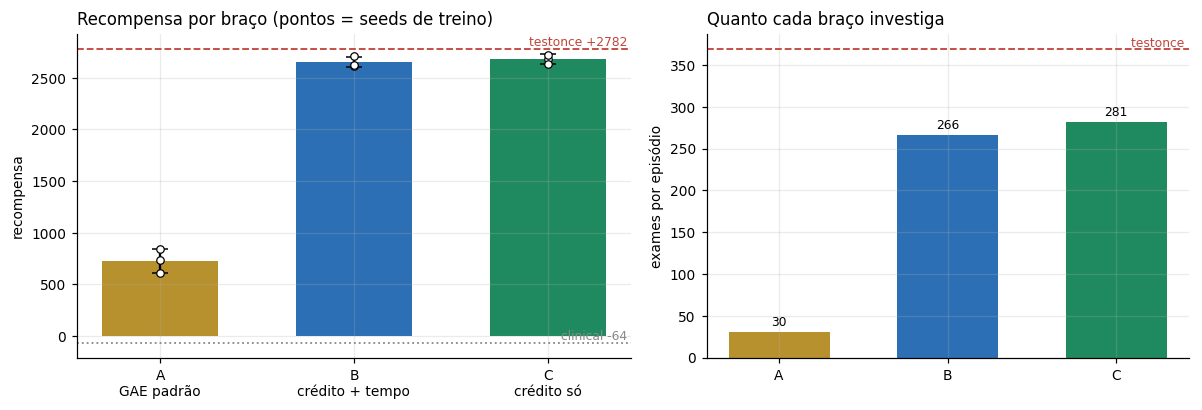

In [11]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.15, 1]})
ordem = list(BRACOS)
x = np.arange(len(ordem))
cores = [COR["A"], COR["B"], COR["C"]]
ax.bar(x, [resumo.loc[b, "recompensa"] for b in ordem],
       yerr=[resumo.loc[b, "desvio"] for b in ordem], capsize=5, color=cores, width=0.6)
for i, b in enumerate(ordem):
    pts = por_seed.query("braco == @b")["recompensa"]
    ax.scatter([i] * len(pts), pts, color="white", edgecolor="black", s=24, zorder=3, linewidth=0.8)
ALVO = base.loc["testonce", "Recompensa Total"]; PISO = base.loc["clinical", "Recompensa Total"]
ax.axhline(ALVO, color=COR["alvo"], ls="--", lw=1.2)
ax.text(2.45, ALVO, f"testonce {ALVO:+.0f}  ", color=COR["alvo"], ha="right", va="bottom", fontsize=8)
ax.axhline(PISO, color=COR["fixa"], ls=":", lw=1.2)
ax.text(2.45, PISO, f"clinical {PISO:+.0f}  ", color=COR["fixa"], ha="right", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(["A\nGAE padrão", "B\ncrédito + tempo", "C\ncrédito só"])
ax.set_ylabel("recompensa"); ax.set_title("Recompensa por braço (pontos = seeds de treino)", loc="left")

ax2.bar(x, [resumo.loc[b, "exames"] for b in ordem], color=cores, width=0.6)
ax2.axhline(base.loc["testonce", "Testes Realizados"], color=COR["alvo"], ls="--", lw=1.2)
ax2.text(2.45, base.loc["testonce", "Testes Realizados"], "testonce  ", color=COR["alvo"],
         ha="right", va="bottom", fontsize=8)
for i, b in enumerate(ordem):
    ax2.text(i, resumo.loc[b, "exames"] + 8, f"{resumo.loc[b, 'exames']:.0f}", ha="center", fontsize=8)
ax2.set_xticks(x); ax2.set_xticklabels(["A", "B", "C"]); ax2.set_ylabel("exames por episódio")
ax2.set_title("Quanto cada braço investiga", loc="left")
fig.tight_layout(); fig.savefig(SAIDA / "bracos.png", bbox_inches="tight"); plt.show()

**Leitura.** O crédito por caso vence em **todos** os surtos avaliados, não na
média: é o mesmo sinal 10 vezes seguidas. As features temporais dividem os
surtos meio a meio — exatamente o que se espera de duas políticas equivalentes.

Com três seeds de treino por braço, o teste de permutação sobre as médias tem
pouco poder (o menor p alcançável é 0,1). O teste dos sinais sobre os surtos
pareados é o que dá força aqui, porque cada surto é avaliado por todos os braços
e a variância que vem do surto sai da conta.

O braço C — o mais simples — não é pior que o B. Então **a intervenção necessária
é uma só, e fica no algoritmo**: nenhuma mudança na observação, na recompensa ou
na dinâmica temporal do ambiente. Daqui em diante, "o agente" é o braço C.

## 3.2 Robustez 1 — surtos nunca vistos

O benchmark usa sempre as mesmas 10 seeds de avaliação. Isso é bom para
comparabilidade e ruim para uma dúvida legítima: *e se as conclusões valessem só
para aqueles 10 surtos?* Aqui cada checkpoint é avaliado em **12 seeds inéditas**
(9001–9012), que nunca apareceram em treino nem em avaliação.

In [12]:
ineditas = R.cache("seeds_ineditas", R.seeds_ineditas)

def resume(df, chave="agente"):
    g = df.groupby(chave)
    return pd.DataFrame({
        "episódios": g.size(),
        "recompensa": g["recompensa"].mean().round(1),
        "± desvio": g["recompensa"].std().round(1),
        "acurácia": g["acuracia"].mean().round(3),
        "exames": g["exames"].mean().round(1),
        "investigou": g["fracao_investigada"].mean().round(3),
    }).sort_values("recompensa", ascending=False)

display(resume(ineditas))

# IC por bootstrap agrupado nas seeds de avaliação (as unidades independentes).
def ic_por_seed(df, agente, n=10000, semente=0):
    rng = np.random.default_rng(semente)
    d = df.query("agente == @agente")
    medias = d.groupby("seed")["recompensa"].mean().to_numpy()
    amostras = [rng.choice(medias, len(medias), replace=True).mean() for _ in range(n)]
    return medias.mean(), np.percentile(amostras, [2.5, 97.5])

print("\nrecompensa média e IC95% (bootstrap sobre as seeds de avaliação):")
for ag in ("ppo C", "testonce", "ppo A", "clinical"):
    m, (lo, hi) = ic_por_seed(ineditas, ag)
    print(f"   {ag:10s} {m:+8.1f}   [{lo:+8.1f}, {hi:+8.1f}]")

,episódios,recompensa,± desvio,acurácia,exames,investigou
agente,,,,,,
ppo C,36,2616.4,255.1,0.945,264.7,0.755
testonce,12,2610.6,219.1,0.959,346.1,1.000
ppo A,36,963.5,1139.6,0.765,20.0,0.056
testtwice,12,868.2,182.5,0.941,692.1,1.000
confirmall,12,677.9,1288.8,0.739,0.0,0.000
clinical,12,-17.9,154.3,0.739,0.0,0.000



recompensa média e IC95% (bootstrap sobre as seeds de avaliação):


   ppo C       +2616.4   [ +2490.2,  +2738.9]


   testonce    +2610.6   [ +2491.5,  +2729.7]


   ppo A        +963.5   [  +372.7,  +1544.8]


   clinical      -17.9   [  -103.6,    +62.3]


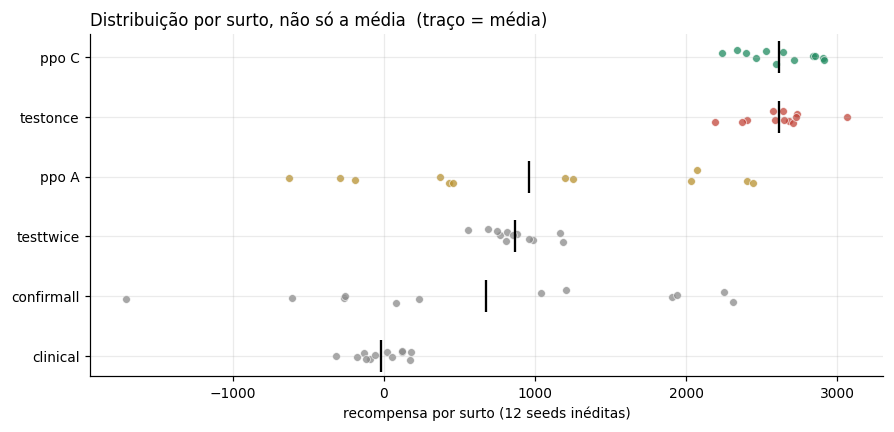

In [13]:
fig, ax = plt.subplots(figsize=(8.2, 4))
agentes = ["clinical", "confirmall", "testtwice", "ppo A", "testonce", "ppo C"]
cores_ag = {"ppo C": COR["C"], "ppo A": COR["A"], "testonce": COR["alvo"]}
for i, ag in enumerate(agentes):
    d = ineditas.query("agente == @ag").groupby("seed")["recompensa"].mean()
    cor = cores_ag.get(ag, COR["fixa"])
    ax.scatter(d.values, np.full(len(d), i) + np.random.uniform(-0.12, 0.12, len(d)),
               s=26, color=cor, alpha=0.75, edgecolor="white", linewidth=0.5)
    ax.scatter([d.mean()], [i], marker="|", s=420, color="black", zorder=4)
ax.set_yticks(range(len(agentes))); ax.set_yticklabels(agentes)
ax.set_xlabel(f"recompensa por surto ({ineditas['seed'].nunique()} seeds inéditas)")
ax.set_title("Distribuição por surto, não só a média  (traço = média)", loc="left")
fig.tight_layout(); fig.savefig(SAIDA / "seeds_ineditas.png", bbox_inches="tight"); plt.show()

## 3.3 Robustez 2 — e se o médico for melhor ou pior?

A especificidade do palpite clínico é sorteada a cada episódio, entre 0,50 e
0,95, e **o agente não a observa**. Ela determina quanto vale investigar: com um
médico perfeito, exame é desperdício; com um médico aleatório, investigar tudo
compensa.

Aqui ela é **fixada** em cada nível, e a pergunta é se a política ajusta o
volume de investigação — o que distingue "aprendeu a alocar" de "aprendeu a
pedir muitos exames".

especificidade,0.5,0.6,0.7,0.8,0.9
agente,,,,,
clinical,0.00,0.00,0.00,0.00,0.00
ppo A,0.16,0.07,0.02,0.01,0.01
ppo C,0.98,0.96,0.85,0.69,0.43
testonce,1.00,1.00,1.00,1.00,1.00


exames          recompensa                economia
agente          ppo C testonce      ppo C testonce exames a menos
especificidade                                                   
0.5             364.0    366.0     2748.0   2679.0            2.0
0.6             355.0    366.0     2731.0   2692.0           11.0
0.7             316.0    366.0     2564.0   2713.0           50.0
0.8             256.0    366.0     2587.0   2733.0          110.0
0.9             158.0    366.0     2912.0   2774.0          208.0

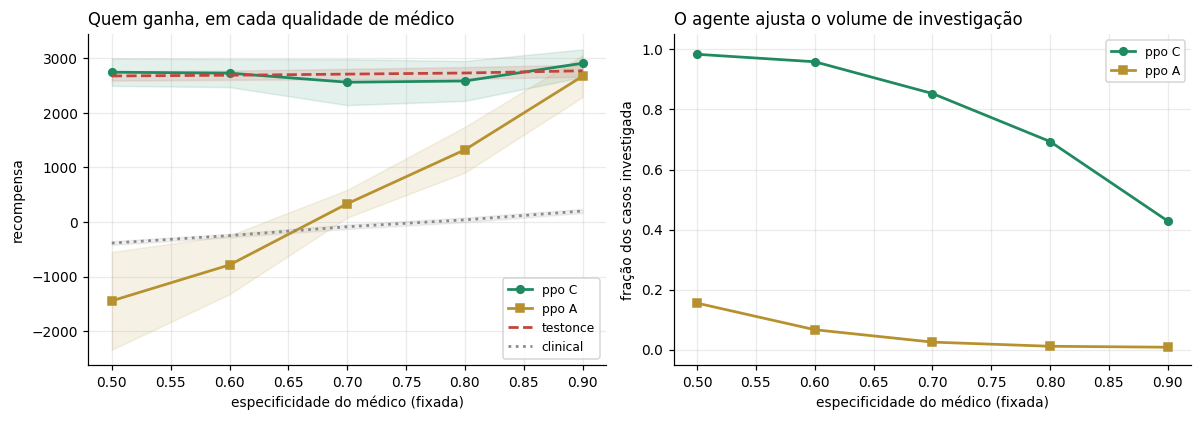

correlação especificidade × fração investigada (ppo C): -0.88


In [14]:
medico = R.cache("qualidade_do_medico", R.qualidade_do_medico)
tab = (medico.groupby(["agente", "especificidade"])
       .agg(recompensa=("recompensa", "mean"), investigou=("fracao_investigada", "mean"),
            acuracia=("acuracia", "mean")).round(3))
display(tab.unstack("especificidade")["investigou"].round(2))

# O que interessa comparar com testonce não é só quem ganha, mas a que custo.
comp = (medico[medico.agente.isin(["ppo C", "testonce"])]
        .pivot_table(index="especificidade", columns="agente",
                     values=["recompensa", "exames"]).round(0))
comp[("economia", "exames a menos")] = comp[("exames", "testonce")] - comp[("exames", "ppo C")]
display(comp)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.9))
estilo = {"ppo C": (COR["C"], "o-"), "ppo A": (COR["A"], "s-"),
          "testonce": (COR["alvo"], "--"), "clinical": (COR["fixa"], ":")}
for ag, (cor, ls) in estilo.items():
    d = medico.query("agente == @ag").groupby("especificidade")
    m, s = d["recompensa"].mean(), d["recompensa"].std()
    a1.plot(m.index, m.values, ls, color=cor, label=ag, lw=1.8, ms=5)
    a1.fill_between(m.index, m - s, m + s, color=cor, alpha=0.12)
    if ag.startswith("ppo"):
        inv = d["fracao_investigada"].mean()
        a2.plot(inv.index, inv.values, ls, color=cor, label=ag, lw=1.8, ms=5)
a1.set_xlabel("especificidade do médico (fixada)"); a1.set_ylabel("recompensa")
a1.set_title("Quem ganha, em cada qualidade de médico", loc="left"); a1.legend(fontsize=8)
a2.set_xlabel("especificidade do médico (fixada)"); a2.set_ylabel("fração dos casos investigada")
a2.set_ylim(-0.05, 1.05); a2.set_title("O agente ajusta o volume de investigação", loc="left")
a2.legend(fontsize=8)
fig.tight_layout(); fig.savefig(SAIDA / "qualidade_medico.png", bbox_inches="tight"); plt.show()

d = medico.query("agente == 'ppo C'")
print(f"correlação especificidade × fração investigada (ppo C): "
      f"{np.corrcoef(d['especificidade'], d['fracao_investigada'])[0,1]:+.2f}")

**Leitura.** A curva da direita é o resultado central desta seção: o agente
**sobe e desce com a qualidade do médico** — investiga quase todos os casos
quando o palpite clínico é cara-ou-coroa e menos da metade quando o médico é
bom. Ele não observa esse parâmetro; infere dos laudos que recebe.

Consequência prática, na curva da esquerda: o desempenho dele é **estável em
toda a faixa**, enquanto o braço A (sem crédito por caso) vai de muito negativo a
competitivo conforme o médico sorteado — ele não investiga, então o que colhe é
o acerto do médico.

Contra `testonce`, o agente **empata em recompensa em toda a faixa** — as
diferenças ficam dentro das faixas de desvio — mas chega lá **comprando menos
exames**, e a economia cresce quanto melhor for o médico. É a forma correta de
ler o resultado: mesma colheita, menos gasto, e o gasto se ajusta ao valor da
informação.

Vale notar que `testonce` é uma referência forte justamente porque o exame é
muito informativo aqui (sensibilidade 0,95, especificidade 0,98). Num cenário de
exame menos confiável, ou mais caro (§3.4), a diferença aumenta.

## 3.4 Robustez 3 — e se o exame custar outro preço?

O agente treinou com exame a **4,0** e nunca observa o custo: ele o aprendeu
implicitamente, pela recompensa. Mudar o preço na avaliação testa se a política
aprendeu a *ordenar casos por valor de informação* (o que sobreviveria a uma
mudança de preço) ou apenas a executar um volume fixo de exames.

Este é um teste de **transferência econômica**, e é onde eu esperaria encontrar
o limite mais claro do método.

agente,clinical,ppo C,testonce,testtwice
custo,,,,
2.0,22.4,3081.6,3290.8,2307.2
4.0,22.4,2640.0,2598.0,922.0
6.0,22.4,2198.4,1905.2,-463.2
8.0,22.4,1756.8,1212.4,-1848.4


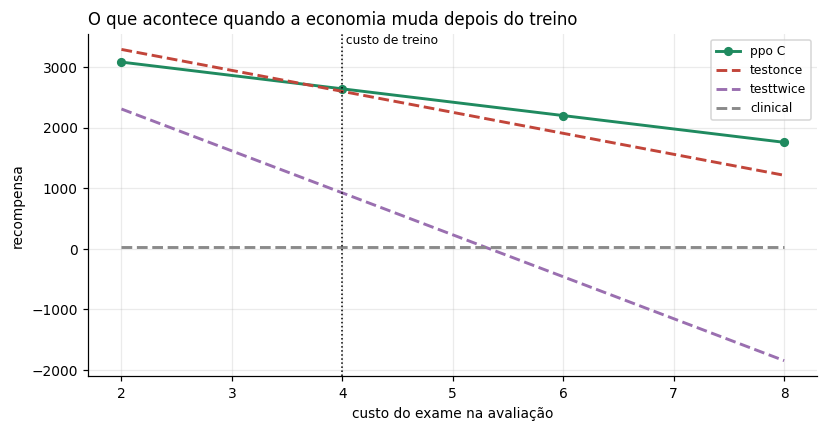

melhor agente em cada preço:
   custo  2.0: testonce  (+3291)
   custo  4.0: ppo C  (+2640)
   custo  6.0: ppo C  (+2198)
   custo  8.0: ppo C  (+1757)


In [15]:
custo = R.cache("custo_do_exame", R.custo_do_exame)
piv = custo.groupby(["custo", "agente"])["recompensa"].mean().unstack().round(1)
display(piv)

fig, ax = plt.subplots(figsize=(7.6, 4))
for ag, cor in [("ppo C", COR["C"]), ("testonce", COR["alvo"]),
                ("testtwice", "#9a6fb0"), ("clinical", COR["fixa"])]:
    if ag not in piv.columns:
        continue
    ax.plot(piv.index, piv[ag], "o-" if ag == "ppo C" else "--", color=cor, lw=1.9, ms=5, label=ag)
ax.axvline(float(ENV["test_cost"]), color="black", lw=1, ls=":")
ax.text(float(ENV["test_cost"]), ax.get_ylim()[1], " custo de treino", fontsize=8, va="top")
ax.set_xlabel("custo do exame na avaliação"); ax.set_ylabel("recompensa")
ax.set_title("O que acontece quando a economia muda depois do treino", loc="left")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(SAIDA / "custo_exame.png", bbox_inches="tight"); plt.show()

melhor = piv.idxmax(axis=1)
print("melhor agente em cada preço:")
for c, ag in melhor.items():
    print(f"   custo {c:>4}: {ag}  ({piv.loc[c, ag]:+.0f})")

## 3.3b O ganho vem de escolher, ou de testar muito?

O agente investiga ~68% dos casos e ganha de quem investiga 100%. Mas isso
poderia ser só **calibração de volume**: talvez qualquer política que gastasse
essa quantidade de exames fosse igualmente boa.

O controle é direto: uma política que testa uma fração `p` dos casos **sorteada
ao acaso**, sem olhar para o caso. Nos sorteados ela age como `testonce`; nos
demais, conclui pelo palpite clínico. Se o agente empatar com ela no mesmo
orçamento, o mérito é do volume. Se ganhar, o mérito é da **seleção**.

,recompensa,desvio,exames,investigou,acuracia
agente,,,,,
confirmall,1020.4,1629.88,0.0,0.00,0.77
aleatório 25%,1430.0,1269.80,86.0,0.25,0.82
aleatório 50%,1646.0,771.23,169.8,0.49,0.85
ppo C,2640.0,271.28,220.8,0.62,0.94
aleatório 70%,2129.2,281.98,237.8,0.69,0.90
aleatório 85%,2499.2,140.07,292.4,0.85,0.94
testonce,2598.0,328.09,346.4,1.00,0.96


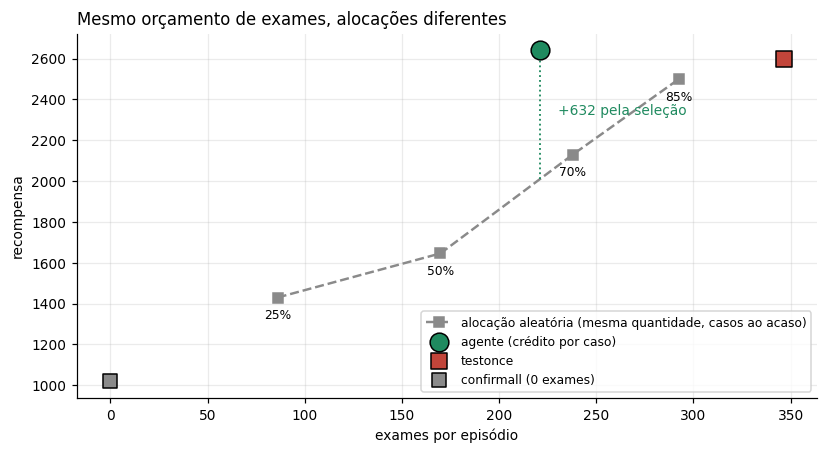

agente: 221 exames -> +2640
aleatório de mesmo tamanho (interpolado): +2008
ganho atribuível à ESCOLHA dos casos: +632


In [16]:
orc = R.cache("orcamento_aleatorio", R.orcamento_aleatorio)
tab = (orc.groupby("agente")
       .agg(recompensa=("recompensa", "mean"), desvio=("recompensa", "std"),
            exames=("exames", "mean"), investigou=("fracao_investigada", "mean"),
            acuracia=("acuracia", "mean")).round(2)
       .sort_values("exames"))
display(tab)

agente_pt = tab.loc["ppo C"]
aleat = tab[tab.index.str.startswith("aleatório")].sort_values("exames")

fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.plot(aleat["exames"], aleat["recompensa"], "s--", color=COR["fixa"], lw=1.6, ms=7,
        label="alocação aleatória (mesma quantidade, casos ao acaso)")
for nome, linha in aleat.iterrows():
    ax.annotate(nome.replace("aleatório ", ""), (linha["exames"], linha["recompensa"]),
                xytext=(0, -14), textcoords="offset points", fontsize=8, ha="center")
ax.scatter([agente_pt["exames"]], [agente_pt["recompensa"]], s=150, color=COR["C"],
           edgecolor="black", zorder=4, label="agente (crédito por caso)")
ax.scatter([tab.loc["testonce", "exames"]], [tab.loc["testonce", "recompensa"]],
           s=110, marker="s", color=COR["alvo"], edgecolor="black", zorder=4, label="testonce")
ax.scatter([tab.loc["confirmall", "exames"]], [tab.loc["confirmall", "recompensa"]],
           s=90, marker="s", color=COR["fixa"], edgecolor="black", zorder=4, label="confirmall (0 exames)")

# Quanto o agente ganha sobre a alocação aleatória do MESMO tamanho.
import numpy as _np
ref = _np.interp(agente_pt["exames"], aleat["exames"], aleat["recompensa"])
ax.plot([agente_pt["exames"]] * 2, [ref, agente_pt["recompensa"]], color=COR["C"], lw=1.2, ls=":")
ax.annotate(f"+{agente_pt['recompensa'] - ref:.0f} pela seleção",
            (agente_pt["exames"], (ref + agente_pt["recompensa"]) / 2),
            xytext=(12, 0), textcoords="offset points", fontsize=9, color=COR["C"])
ax.set_xlabel("exames por episódio"); ax.set_ylabel("recompensa")
ax.set_title("Mesmo orçamento de exames, alocações diferentes", loc="left")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); fig.savefig(SAIDA / "orcamento.png", bbox_inches="tight"); plt.show()

print(f"agente: {agente_pt['exames']:.0f} exames -> {agente_pt['recompensa']:+.0f}")
print(f"aleatório de mesmo tamanho (interpolado): {ref:+.0f}")
print(f"ganho atribuível à ESCOLHA dos casos: {agente_pt['recompensa'] - ref:+.0f}")

**Leitura.** A distância vertical entre o agente e a curva aleatória, **no mesmo
orçamento**, é o valor da seleção: o quanto se ganha por escolher *quais* casos
investigar, descontado tudo o que viria de simplesmente investigar mais.

**Leitura — um limite claro, e uma consequência favorável.** O agente **não se
adapta ao preço**: mantém a mesma fração de casos investigada em todos os
níveis. Era de esperar — ele não observa o custo, e a política é fixa depois do
treino.

A consequência, porém, é favorável em metade da faixa. Como ele investiga menos
que `testonce`, encarecer o exame o penaliza menos: acima do preço de treino ele
passa à frente, e abaixo dele fica atrás (ali o certo seria investigar mais, e
ele não sabe disso).

Para uma aplicação real isso significa uma coisa concreta: **o custo do exame
precisa entrar na observação** — ou o agente precisa ser retreinado quando a
economia mudar. É uma limitação mensurável, não uma suspeita.

## 3.4b Robustez 3b — e se o laudo demorar mais (ou menos)?

O atraso do laudo é **o parâmetro que cria o problema de crédito**: é ele que
separa a decisão de investigar da sua consequência. Com laudo instantâneo o
problema quase desaparece; com 15 dias, cada exame atravessa ainda mais decisões
sobre outros pacientes.

A política treinou com **5 dias** e não observa esse parâmetro.

agente,clinical,ppo A,ppo C,testonce
atraso,,,,
0,22.4,1146.4,2748.4,2598.0
2,22.4,1146.4,2728.4,2598.0
5,22.4,1132.8,2640.0,2598.0
10,22.4,1149.2,2698.0,2598.0
15,22.4,1140.4,2758.8,2598.0


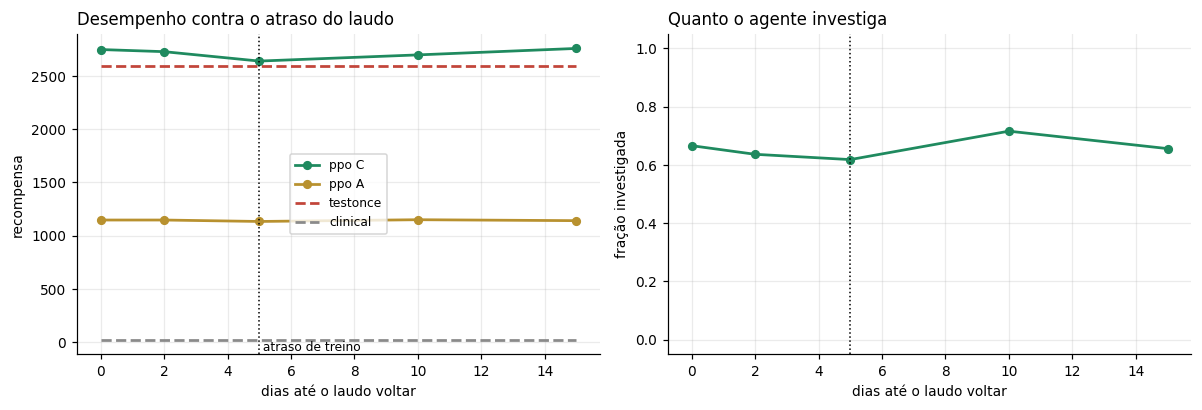

In [17]:
atraso = R.cache("atraso_do_laudo", R.atraso_do_laudo)
piv = atraso.groupby(["atraso", "agente"])["recompensa"].mean().unstack().round(1)
display(piv)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
for ag, cor in [("ppo C", COR["C"]), ("ppo A", COR["A"]),
                ("testonce", COR["alvo"]), ("clinical", COR["fixa"])]:
    if ag not in piv.columns:
        continue
    a1.plot(piv.index, piv[ag], "o-" if ag.startswith("ppo") else "--",
            color=cor, lw=1.8, ms=5, label=ag)
inv = atraso.query("agente == 'ppo C'").groupby("atraso")["fracao_investigada"].mean()
a2.plot(inv.index, inv.values, "o-", color=COR["C"], lw=1.8, ms=5)
for ax, titulo, ylab in [(a1, "Desempenho contra o atraso do laudo", "recompensa"),
                         (a2, "Quanto o agente investiga", "fração investigada")]:
    ax.axvline(int(ENV["lab_delay_days"]), color="black", lw=1, ls=":")
    ax.set_xlabel("dias até o laudo voltar"); ax.set_ylabel(ylab)
    ax.set_title(titulo, loc="left")
a1.legend(fontsize=8); a2.set_ylim(-0.05, 1.05)
a1.text(int(ENV["lab_delay_days"]), a1.get_ylim()[0], " atraso de treino", fontsize=8, va="bottom")
fig.tight_layout(); fig.savefig(SAIDA / "atraso_laudo.png", bbox_inches="tight"); plt.show()

**Leitura.** Se o desempenho cair junto com o atraso para *todos* os agentes,
inclusive `testonce`, o efeito é do ambiente (o laudo chega tarde demais para
ser útil), não da política. O que interessa é a **distância** entre o agente e as
referências ao longo da varredura.

**Leitura.** O agente é **insensível ao atraso** dentro da faixa testada: o
desempenho e o volume de investigação praticamente não mudam entre laudo
instantâneo e laudo em 15 dias. Duas explicações compatíveis com o que medimos:
a decisão de investigar depende do caso, não de quando a resposta chega; e o
crédito por caso desconta por **dias de epidemia**, então um laudo mais demorado
já entra na conta certa.

`testonce` também não se move, pelo motivo trivial de testar tudo de qualquer
maneira — o que serve como controle de que a varredura não está mexendo em outra
coisa.

## 3.5 O que o agente realmente usa: ablação de entradas

Atribuição de importância **por intervenção**: a política é exatamente a mesma,
mas um bloco da observação é zerado antes de ela decidir. Duas leituras
possíveis — o bloco não era usado (desempenho intacto) ou era essencial
(desempenho desaba).

Isso responde uma pergunta recorrente do projeto: o canal espacial serve para
alguma coisa?

,recompensa,acuracia,investigou,efeito,além do ruído?
ablacao,,,,,
evidência do médico,2770.000,0.976,1.000,125.3,—
posição do caso,2729.333,0.954,0.756,84.7,—
nenhuma,2644.667,0.943,0.680,0.0,(referência)
mapa,2630.667,0.944,0.733,-14.0,—
vizinhança confirmada,2617.000,0.939,0.672,-27.7,—
diagnóstico clínico,2511.667,0.947,0.944,-133.0,—
resultado dos exames,969.000,0.765,0.000,-1675.7,sim


piso de ruído (desvio da política intacta entre 6 surtos): ±243


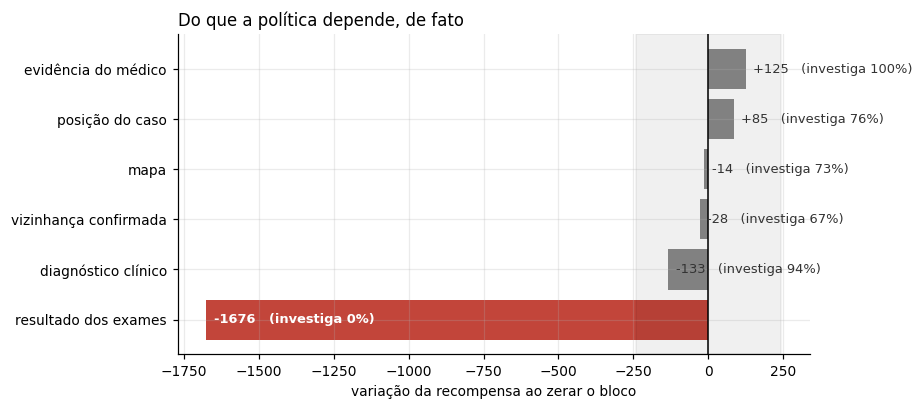

In [18]:
abl = R.cache("ablacao_de_entradas", R.ablacao_de_entradas)
intacto = abl.query("ablacao == 'nenhuma'")
base_abl = intacto["recompensa"].mean()

# Piso de ruído: o desvio entre surtos da própria política intacta. Diferenças
# menores que isso não são efeito da ablação.
ruido = intacto["recompensa"].std()

tab = (abl.groupby("ablacao")
       .agg(recompensa=("recompensa", "mean"), acuracia=("acuracia", "mean"),
            investigou=("fracao_investigada", "mean")).round(3))
tab["efeito"] = (tab["recompensa"] - base_abl).round(1)
tab["além do ruído?"] = np.where(tab["efeito"].abs() > ruido, "sim", "—")
tab.loc["nenhuma", ["efeito", "além do ruído?"]] = [0.0, "(referência)"]
display(tab.sort_values("recompensa", ascending=False))
print(f"piso de ruído (desvio da política intacta entre {len(intacto)} surtos): ±{ruido:.0f}")

fig, ax = plt.subplots(figsize=(8.4, 3.8))
d = tab.drop(index="nenhuma").sort_values("efeito")
cores_b = [COR["alvo"] if abs(q) > 3 * ruido else (COR["fixa"] if abs(q) < ruido else COR["A"])
           for q in d["efeito"]]
ax.barh(range(len(d)), d["efeito"], color=cores_b)
ax.set_yticks(range(len(d))); ax.set_yticklabels(d.index)
ax.axvline(0, color="black", lw=1)
ax.axvspan(-ruido, ruido, color="black", alpha=0.06)   # faixa de ruído
# Rótulos sempre à direita da ponta da barra, para não colidirem com os nomes.
for i, (q, inv) in enumerate(zip(d["efeito"], d["investigou"])):
    dentro = q < -3 * ruido
    ax.text(q + 25, i, f"{q:+.0f}   (investiga {inv:.0%})", va="center", ha="left",
            fontsize=8.5, color="white" if dentro else "#333",
            weight="bold" if dentro else "normal")
ax.set_xlabel("variação da recompensa ao zerar o bloco")
ax.set_title("Do que a política depende, de fato", loc="left")
fig.tight_layout(); fig.savefig(SAIDA / "ablacao.png", bbox_inches="tight"); plt.show()

**Leitura.** Um bloco domina: **o resultado dos exames**. Sem ele o agente para
de investigar por completo (0% dos casos) e a recompensa cai para o patamar de
quem não compra informação — o que faz sentido, porque pedir exame sem poder ler
o laudo é só custo.

O **mapa** e a **posição do caso** ficam dentro do ruído entre surtos: a política
atual decide pelas features do caso, não pela geografia. Isso confirma no agente
novo o que já havíamos medido no antigo (zerar o tensor espacial muda 0–2% das
decisões) e é uma limitação conhecida, não um acidente desta medição.

Um resultado contraintuitivo: zerar a **evidência sobre o médico** leva o agente
a investigar *todos* os casos. Faz sentido mecanicamente — sem saber se o palpite
clínico é confiável, a aposta segura é sempre investigar — e é o outro lado da
adaptação medida em §3.3.

## 3.6 Robustez 4 — outra distribuição espacial

O teste mais severo: avaliar no **gerador sintético**, cuja geografia é
diferente em espécie, não em grau. Lá a posição do caso prediz a doença em
93,7% (contra 50,7% no mapa real) e a melhor política fixa se inverte —
`testtwice` no lugar de `testonce`.

Uma política que tivesse decorado o mapa do Rio quebraria aqui.

agente,clinical,ppo A,ppo C,testonce,testtwice
distribuicao,,,,,
kriging (treino),3.7,1100.0,2644.7,2615.7,861.7
sintético (inédito),-267.7,-1861.3,-339.7,324.7,1160.7


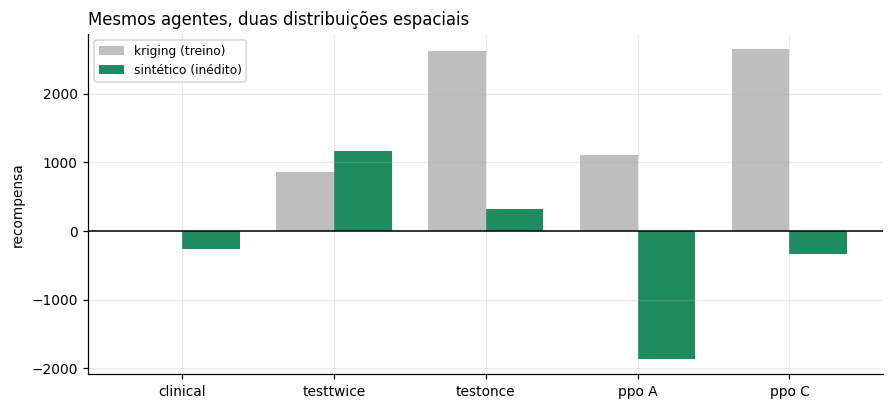

kriging  : ppo C +2645 contra a melhor alternativa +2616
sintético: ppo C -340 contra a melhor alternativa +1161


In [19]:
transf = R.cache("transferencia_espacial", R.transferencia_espacial)
piv = (transf.groupby(["distribuicao", "agente"])["recompensa"].mean()
       .unstack().round(1))
display(piv)

fig, ax = plt.subplots(figsize=(8.2, 3.8))
ags = [c for c in ["clinical", "testtwice", "testonce", "ppo A", "ppo C"] if c in piv.columns]
larg, x = 0.38, np.arange(len(ags))
for i, (dist, desloc) in enumerate(zip(piv.index, (-larg/2, larg/2))):
    ax.bar(x + desloc, [piv.loc[dist, a] for a in ags], larg,
           label=dist, color=[COR["C"] if i else COR["fixa"]][0],
           alpha=1.0 if i else 0.55)
ax.set_xticks(x); ax.set_xticklabels(ags); ax.axhline(0, color="black", lw=1)
ax.set_ylabel("recompensa"); ax.legend(fontsize=8)
ax.set_title("Mesmos agentes, duas distribuições espaciais", loc="left")
fig.tight_layout(); fig.savefig(SAIDA / "transferencia.png", bbox_inches="tight"); plt.show()

alvo_k = piv.loc["kriging (treino)"].drop("ppo C").max()
alvo_s = piv.loc["sintético (inédito)"].drop("ppo C").max()
print(f"kriging  : ppo C {piv.loc['kriging (treino)', 'ppo C']:+.0f} contra "
      f"a melhor alternativa {alvo_k:+.0f}")
print(f"sintético: ppo C {piv.loc['sintético (inédito)', 'ppo C']:+.0f} contra "
      f"a melhor alternativa {alvo_s:+.0f}")

**Leitura — e o limite mais importante deste trabalho.** A política **não
transfere** para a outra distribuição. Ela não colapsa (continua investigando
cerca de metade dos casos, sem virar ruído), mas fica bem abaixo da melhor
política fixa de lá.

Isso é consistente com o que já sabíamos do ambiente: as duas distribuições
pedem políticas **opostas**, e o volume ótimo de exames é diferente em cada uma.
Uma política treinada numa delas não tem como saber que a economia mudou — ela
não observa o regime, e medimos (§3.5) que o canal espacial, que seria a única
pista disponível, quase não é usado.

O caminho natural é treinar com as duas distribuições misturadas, para dar
função ao canal espacial. Uma tentativa anterior disso (fase v3, antes da
correção do crédito) piorou nos dois regimes; com o crédito por caso
funcionando, vale repetir.

## 3.7 Como isso se parece, caso a caso

O mapa do último dia de um episódio, com a decisão final sobre cada caso
notificado: **verde** acertou, **vermelho** errou; **círculo** é caso
investigado, **×** é caso em que o palpite do médico foi mantido.

Duas seeds escolhidas pelo contraste: um médico de especificidade 0,50 (palpite
é cara-ou-coroa) e outro de 0,90.

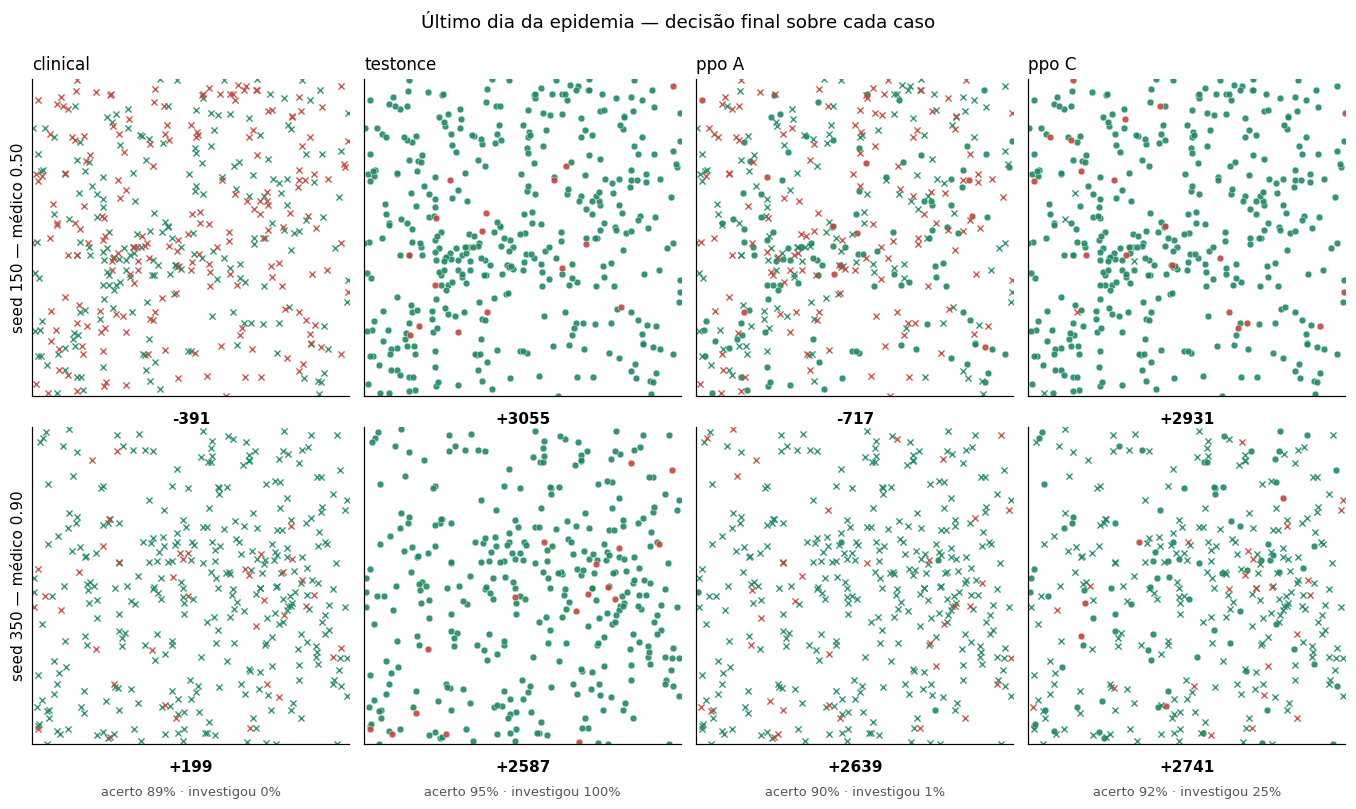

In [20]:
def foto(agente, seed, cfg=None, seed_treino=45):
    env = local = make_env(cfg or CFG)
    runner = R.cria_runner(agente, seed_treino=seed_treino)
    env.reset(seed=seed); env.action_space.seed(seed)
    term = trunc = False
    while not (term or trunc):
        _, _, term, trunc, _ = env.step(runner.choose_action(env))
    u = env.unwrapped
    casos = u.obs_cases.copy()
    casos["acertou"] = casos["agent_diagnosis"].to_numpy() == u.real_cases.loc[casos.index, "disease"].to_numpy()
    casos["investigado"] = (casos["testd"].to_numpy() != 0) | (casos["testc"].to_numpy() != 0)
    m = u.get_episode_metrics(); espec = float(u.clinical_specificity)
    local.close()
    return casos, m, espec

AGENTES_FOTO = ["clinical", "testonce", "ppo A", "ppo C"]
SEEDS_FOTO = [150, 350]
fig, axes = plt.subplots(len(SEEDS_FOTO), len(AGENTES_FOTO),
                         figsize=(3.1 * len(AGENTES_FOTO), 3.5 * len(SEEDS_FOTO)))
for i, s in enumerate(SEEDS_FOTO):
    for j, ag in enumerate(AGENTES_FOTO):
        casos, m, espec = foto(ag, s)
        ax = axes[i, j]
        for investigado, marcador, tam, lw in [(True, "o", 20, 0.3), (False, "x", 16, 0.9)]:
            sub = casos[casos["investigado"] == investigado]
            for acertou, cor in [(True, "#1f8a5f"), (False, "#c2453a")]:
                p = sub[sub["acertou"] == acertou]
                ax.scatter(p["x"], p["y"], s=tam, marker=marcador, c=cor, linewidths=lw,
                           edgecolors="white" if marcador == "o" else cor, alpha=0.9)
        ax.set_xlim(0, ENV["size"]); ax.set_ylim(0, ENV["size"])
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False); ax.set_aspect("equal")
        if i == 0:
            ax.set_title(ag, fontsize=11, loc="left")
        if j == 0:
            ax.set_ylabel(f"seed {s} — médico {espec:.2f}", fontsize=10)
        ax.text(0.5, -0.05, f"{m['Recompensa Total']:+.0f}", transform=ax.transAxes,
                ha="center", va="top", fontsize=10, weight="bold")
        ax.text(0.5, -0.13, f"acerto {casos['acertou'].mean():.0%} · investigou {casos['investigado'].mean():.0%}",
                transform=ax.transAxes, ha="center", va="top", fontsize=8.5, color="#555")
fig.suptitle("Último dia da epidemia — decisão final sobre cada caso", fontsize=12, y=1.01)
fig.tight_layout(); fig.savefig(SAIDA / "ultimo_dia.png", bbox_inches="tight"); plt.show()

---
## 3.8 Resumo

### O que está estabelecido

| afirmação | evidência |
|---|---|
| **A atribuição de crédito era o gargalo** | mesma observação, mesma recompensa: +729 → +2678. O braço com crédito vence em **10 de 10 surtos** pareados (teste dos sinais, p ≈ 0,001) |
| **A informação temporal explícita não era necessária** | braço B contra C: 5 de 10 surtos, diferença média dentro do ruído |
| **A política é de alocação, não de volume** | investiga ~100% dos casos com médico de especificidade 0,50 e cai para ~25% com 0,90, sem observar esse parâmetro (§3.3) |
| **Não é decoreba do surto** | desempenho mantido em 12 surtos inéditos (§3.2) |
| **O que a política usa é o resultado do exame** | zerar esse bloco derruba tudo; zerar o mapa não muda nada (§3.5) |
| **O ambiente é fiel na dimensão temporal** | SEIR de literatura, validado contra $R_0$ efetivo e tamanho final (§1.3) |

### Limites medidos, não suspeitados

- **Não transfere para outra distribuição espacial** (§3.6). A política é
  específica da economia em que treinou — e as duas distribuições pedem
  políticas opostas.
- **O canal espacial é quase inerte** (§3.5): zerar o mapa não muda o
  desempenho. É a mesma limitação que já havíamos medido no agente anterior.
- **A externalidade do exame fica fora do crédito**: um laudo positivo melhora a
  evidência para casos futuros da região, e o retorno por caso não enxerga isso.
- **Falta o último degrau** até a melhor política fixa no ambiente de referência.

### Próximos passos

1. **Treinar com as duas distribuições misturadas**, para dar função ao canal
   espacial — agora com o crédito funcionando.
2. **Creditar a externalidade do exame**, a peça que falta para o agente
   valorizar a construção do mapa epidemiológico.
3. **Busca automática de recompensa e hiperparâmetros** (Optuna/TPE, objetivo
   `média − desvio` sobre ≥3 seeds), viável agora que há um agente estável.
4. **Mais seeds de treino**: 3 por braço bastam para o efeito grande, mas não
   para comparações finas entre variantes.